# Lecture 9 — Hydrostatic Equilibrium & Temperature Structure

*Stellar Spectroscopy from Scratch — a torch/MPS implementation, with each part validated against reference calculations*

*Yuan-Sen Ting*

*The **hydrostatic** half of the model atmosphere — the grey/Hopf temperature, the radiation pressure, and Kurucz's **TTAUP** predictor-corrector integration of $dP/d\tau = g/\kappa$ in log-pressure — is rebuilt in **`torch`** that runs on the GPU (Apple **MPS** or **CUDA**, with a CPU fallback in fp64). The lecture's new pedagogy is the **vectorization budget**: the temperature, the grid, and the radiation pressure are evaluated for **all 80 depth layers at once** as tensor ops; the TTAUP march, by contrast, is a true recurrence — its 4-term Adams history couples each layer to the previous four, so it remains a justified loop over a fixed, small number of layers, exactly as the production `kgpu` engine keeps it a depth march. It ends with a **comparison cell** that validates the torch structure ($P_{\rm gas}$, $\mathrm{RHOX}$) against the reference to the documented float floor. The notebook imports neither `kgpu` nor pykurucz.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Write **hydrostatic equilibrium** in the form the codes integrate, $dP_{\rm total}/d\tau = g/\kappa$, and recover the clean identity $P_{\rm total} = g\,m$ for column mass $m$.
- Evaluate the grey/Hopf **temperature** law and the ATLAS12 **log-$\tau$ grid** as torch tensor ops over all 80 layers at once, and carry the (tiny) **radiation pressure** $P_{\rm rad} = 2.521\times10^{-15}\max(T^4, \tfrac12 T_{\rm eff}^4)$ as an elementwise expression.
- Explain why the cold start integrates in **log pressure** (many decades, smoothest integrand) and uses the placeholder opacity $\kappa\equiv1$.
- Recognise that the **TTAUP predictor-corrector** is a true recurrence — the rolling log-$P$ history couples layer $j$ to $j-1\ldots j-4$ — so it remains a justified fixed-depth loop, with the per-layer scalar arithmetic still done torch-native on the device, mirroring `kgpu`'s depth march.
- Reproduce the production code's **evaluate-then-check** corrector ordering and its radiation-pressure subtraction, and **validate** the torch gas pressure and column mass against the reference to the documented float floor (the residual Lecture 1 deferred, now closed).

## Setup and the reference

We begin by picking the **compute device** once and a working **dtype** to match (MPS / CUDA $\to$ fp32, CPU $\to$ fp64), and load the **reference** grey structure we validate against — `reference/L1.npz`, which carries `grey_tau`, `grey_T`, `grey_pgas`, and `grey_rhox` (the same Sun, $T_{\rm eff}=5770\,$K, $\log g = 4.44$). The grid, the temperature, and the radiation pressure are torch tensors on the device; the TTAUP march does its per-layer scalar work on the device too; only the closing comparison moves the result to the CPU as NumPy.

In [1]:
import pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
})

# pick the compute device once, and the working dtype to match (MPS/CUDA -> fp32, CPU -> fp64)
if torch.backends.mps.is_available():
    DEVICE, DTYPE = torch.device("mps"), torch.float32
elif torch.cuda.is_available():
    DEVICE, DTYPE = torch.device("cuda"), torch.float32
else:
    DEVICE, DTYPE = torch.device("cpu"), torch.float64

def t(x):
    """Move a python/numpy scalar or array onto the chosen device at the working dtype."""
    return torch.as_tensor(np.asarray(x), dtype=DTYPE, device=DEVICE)

# the precomputed reference grey structure for this lecture (the NumPy-edition parity oracle)
REF = np.load(pathlib.Path("..") / "reference" / "L1.npz")

def compare(name, ours, ref, tol=1e-6):
    """Report how closely a from-scratch torch array matches the reference; move it to CPU/NumPy first."""
    if isinstance(ours, torch.Tensor):
        # MPS has no float64: move to CPU FIRST, then cast (a direct .to(cpu, float64) raises on MPS)
        ours = ours.detach().cpu().to(torch.float64).numpy()
    ours, ref = np.asarray(ours, float), np.asarray(ref, float)
    denom = np.where(ref != 0.0, np.abs(ref), 1.0)
    rel = float(np.max(np.abs(ours - ref) / denom))
    tag = "exact" if rel < 1e-12 else ("agree" if rel < tol else "CHECK")
    print(f"{name:28s}  max|rel diff| = {rel:.2e}   [{tag}]")
    return rel

# the Sun: effective temperature [K] and log surface gravity [cgs]
TEFF, LOGG = 5770.0, 4.44
g_cgs = 10.0**LOGG          # surface gravity g [cm s^-2]

print(f"device = {DEVICE.type}   working dtype = {str(DTYPE).split('.')[-1]}")
print(f"Sun: Teff = {TEFF:.0f} K   log g = {LOGG}   g = {g_cgs:.3e} cm/s^2")
print("reference values loaded:", ", ".join(REF.files))

device = mps   working dtype = float32
Sun: Teff = 5770 K   log g = 4.44   g = 2.754e+04 cm/s^2
reference values loaded: grey_tau, grey_T, grey_pgas, grey_rhox, planck_freq, planck_T, planck_B


## Introduction: building the atmosphere we have been given

For eight lectures the **model atmosphere** has been a given. We took its run of temperature, gas pressure, and density with depth — the columns of a `.atm` file — and on top of it built the equation of state, the continuous and line opacities, and the radiative-transfer solver, until we reproduced the reference solar spectrum to the relevant numerical floor. But where did that atmosphere come from? In this static, plane-parallel setup the two *structural* equilibrium constraints are **hydrostatic equilibrium**, that the gas neither collapses under its own weight nor blows away, and **radiative equilibrium**, that the energy carried outward by radiation is conserved at every depth; closing the model also requires an equation of state, opacities, a composition, boundary conditions, and a convection treatment.

This lecture builds the first structural constraint. It is the start of the **inverse half** of the course: instead of taking the structure and computing the spectrum, we compute the structure itself from the two numbers that fix the grey cold start of a star — its effective temperature $T_{\rm eff}$ and its surface gravity $\log g$. A full model also fixes the composition and microturbulence; in the simplified grey setup here, $T_{\rm eff}$ and $\log g$ are enough.

Lecture 1 already built most of the pieces we need here. It wrote down the **grey/Hopf temperature law** $T(\tau)$, laid out the **80-layer optical-depth grid**, and introduced **hydrostatic equilibrium** in optical depth, $dP/d\tau = g/\kappa$. It also took one shortcut: on the cold start it set $\kappa\equiv1$, integrated the balance by hand to the one-line result $P_{\rm total}=g\tau$, and found it agreed with the reference only to about one part in $10^{5}$.

That one part in $10^{5}$ is worth being precise about, because it is *not* a flaw in the closed form. For $\kappa\equiv1$ and a zero-pressure top boundary, $P_{\rm total}=g\tau$ is the **exact analytic solution** of the hydrostatic equation, not an approximation to it. The residual comes from the things the one-liner left out: the production code's boundary seed, its finite-grid predictor-corrector, its radiation-pressure increment and subtraction, and the fact that the reference array is a *gas* pressure while $g\tau$ is a *total* pressure. **Reproducing that stored gas pressure to the float floor is the one genuinely new thing this lecture does.**

The temperature grid and radiation-pressure terms are ordinary elementwise tensor expressions over all 80 layers. The hydrostatic march is the exception: the rolling Adams history couples layer $j$ to $j-1\ldots j-4$, so it is a real recurrence and remains a justified fixed-depth loop, with scalar torch tensors on the device.

![From $T_{\rm eff}$ and $\log g$: the grey temperature law and the hydrostatic integration of $dP/d\tau=g/\kappa$ down the optical-depth grid give the run of temperature, pressure, and density with depth.](resources/figures/s8_hydrostatic.png)

## Hydrostatic equilibrium, in the form the codes integrate

The first lecture introduced hydrostatic equilibrium — the balance between the pressure gradient and the weight of the overlying gas — and rewrote it in **optical depth** $\tau$, the variable the radiation field cares about. With height $z$ measured upward, $\tau$ and column mass increasing inward, gravity $g$ constant across the thin photosphere, and $\kappa$ a Rosseland mass opacity in $\mathrm{cm^2\,g^{-1}}$, the plane-parallel hydrostatic equation becomes

$$
\frac{dP}{d\tau} = \frac{g}{\kappa}.
$$

Read it as a statement about the column mass: since $dP/dm=g$, integrating it gives the weight per unit area of the overlying gas, $g\,m$. With the usual zero-pressure top boundary this is just

$$
P_{\rm total}=g\,m.
$$

Here $m$ is the **column mass**, the grams of material above a square centimetre; Kurucz calls this quantity `RHOX`, and it is a single compound symbol $m=\int_z^\infty\rho\,dz'$, *not* the local density $\rho$ multiplied by a depth coordinate $x$. The optical-depth form makes the opacity explicit: where the gas is more opaque, a given range of $\tau$ spans less pressure, because one reaches optical depth one in less material. In this atmosphere-construction context, $\tau$ means **Rosseland** optical depth and $\kappa$ the **Rosseland-mean opacity**, unless stated otherwise.

So far this is all Lecture 1. What that lecture did *not* do is integrate the equation on the production grid. The rest of this lecture reproduces that discrete integration: the same boundary convention, the same radiation-pressure treatment, and the same predictor-corrector in log pressure.

## Recap (Lecture 1): the grey/Hopf temperature

The temperature structure is the *input* to the pressure integration. Lecture 1 derived it in full from the grey transfer equation; here we only need the result. The grey/Hopf law is

$$
T(\tau)=T_{\rm eff}\left[\frac34\left(0.710+\tau-0.1331\,e^{-3.4488\tau}\right)\right]^{1/4}.
$$

This is Kurucz's analytic exponential fit to the Hopf function. The implementation is a pure elementwise torch function: every depth layer is evaluated in one tensor call, and the bracket is clamped before the fourth root so the power never sees a negative argument. The clamp is a safety guard; it never changes a physical grey atmosphere.

In [2]:
def grey_temperature(teff, tauros):
    """Eddington-Kurucz grey T(tau), evaluated elementwise on the chosen torch device."""
    bracket = 0.75 * (0.710 + tauros - 0.1331 * torch.exp(-3.4488 * tauros))
    bracket = torch.clamp_min(bracket, torch.as_tensor(1.0e-300, dtype=DTYPE, device=DEVICE))
    return torch.as_tensor(float(teff), dtype=DTYPE, device=DEVICE) * torch.pow(bracket, 0.25)

## Recap (Lecture 1): the optical-depth grid

The grid is the literal ATLAS12 `CALCULATE` card default: **80 layers** uniform in $\log\tau$, the first at $\log\tau=-6.875$ and spaced **0.125 dex** apart. It spans nearly ten decades, from $\tau\simeq1.3\times10^{-7}$ at the top to $\tau=10^3$ at the base.

In NumPy this was a small loop-free vector expression; on the GPU it is the same idea, but the ramp and the power of ten are torch tensors resident on `DEVICE`. The temperature law then broadcasts over the full 80-layer vector in one elementwise kernel.

In [3]:
NRHOX = 80
TAU1LG = torch.as_tensor(-6.875, dtype=DTYPE, device=DEVICE)
STEPLG = torch.as_tensor(0.125, dtype=DTYPE, device=DEVICE)

layer = torch.arange(NRHOX, dtype=DTYPE, device=DEVICE)
tau = torch.pow(torch.as_tensor(10.0, dtype=DTYPE, device=DEVICE), TAU1LG + STEPLG * layer)
T = grey_temperature(TEFF, tau)

print(f"{NRHOX} layers on {DEVICE.type}: tau = {tau[0].detach().cpu().to(torch.float64):.3e} .. {tau[-1].detach().cpu().to(torch.float64):.3e}")
print(f"T(top) = {T[0].detach().cpu().to(torch.float64):.1f} K    T(bottom) = {T[-1].detach().cpu().to(torch.float64):.1f} K")

80 layers on mps: tau = 1.334e-07 .. 1.000e+03
T(top) = 4679.7 K    T(bottom) = 30200.8 K


The first parity check is the recap itself: the optical-depth grid and the Hopf temperature must reproduce the reference arrays from Lecture 1. On the CPU fp64 fallback these are at the roundoff floor of the two libraries; on MPS/CUDA the accepted floor is the usual fp32 one.

In [4]:
# comparison-reference cell: REF[...] is the NumPy-edition parity oracle
compare("grey_tau", tau, REF["grey_tau"])
compare("grey_T",   T,   REF["grey_T"])

grey_tau                      max|rel diff| = 1.29e-07   [agree]
grey_T                        max|rel diff| = 1.04e-07   [agree]


1.0422826089813308e-07

## Radiation pressure

The hydrostatic equation supports the **total** pressure, but the equation of state and opacity calculations need the **gas** pressure. The two differ by radiation pressure (and, in more complete models, turbulent pressure):

$$
P_{\rm total}=P_{\rm gas}+P_{\rm rad}+P_{\rm turb}.
$$

Kurucz carries the radiation-pressure coefficient $\tfrac13 a_{\rm rad}$ as

$$
2.521\times10^{-15},
$$

so the grey cold start uses

$$
P_{\rm rad,k}(\tau)
=
2.521\times10^{-15}
\max\!\left(T^4,\frac12T_{\rm eff}^4\right).
$$

The floor at $\tfrac12T_{\rm eff}^4$ keeps the upper boundary well behaved. The integrator actually needs the **run** relative to the top layer, not the absolute constant offset, so we store

$$
P_{\rm rad}(\tau)-P_{\rm rad}(0).
$$

This is another branchless elementwise tensor expression: `torch.maximum` selects the larger fourth-power term in every lane, and `pturb` is an all-zero tensor on the cold start.

In [5]:
teff_t = torch.as_tensor(float(TEFF), dtype=DTYPE, device=DEVICE)
pradk = torch.as_tensor(2.521e-15, dtype=DTYPE, device=DEVICE) * torch.maximum(
    T**4,
    teff_t**4 / 2.0,
)
prad = pradk - pradk[0]
pturb = torch.zeros_like(tau)

print(f"P_rad(top) = {pradk[0].detach().cpu().to(torch.float64):.3e}   P_rad(bottom) = {pradk[-1].detach().cpu().to(torch.float64):.3e} dyn/cm^2")
print("only the increment P_rad(tau) - P_rad(0) enters the hydrostatic balance")

P_rad(top) = 1.397e+00   P_rad(bottom) = 2.097e+03 dyn/cm^2
only the increment P_rad(tau) - P_rad(0) enters the hydrostatic balance


## Why the cold start uses $\kappa\equiv1$

Hydrostatic equilibrium needs the opacity $\kappa(\tau)$, but the opacity depends on temperature, pressure, and composition through the equation of state and the absorption coefficients. We cannot compute the real Rosseland opacity until we already have a structure. This is the bootstrap problem of model-atmosphere construction.

The production code breaks the loop with a **cold start**. On the very first pass the Rosseland table is empty, and an empty table returns a placeholder opacity of unity:

$$
\kappa_{\rm Ross}\equiv1.
$$

That first pressure structure is intentionally crude; ATLAS later rebuilds the real Rosseland mean from the equation of state and iterates the structure. We are reproducing exactly this first grey model. There is one boundary convention: the top layer is seeded with $\kappa_0=0.1$ to set the starting pressure, while the cold-start opacity used after evaluation is unity.

## Integrating in log pressure, and why

Pressure spans many decades between the top and bottom of the atmosphere. The natural variable for the integration is therefore

$$
p=\ln P_{\rm total},
$$

and the grid variable is

$$
u=\ln\tau.
$$

Using the chain rule,

$$
\frac{dp}{du}
=
\frac{1}{P_{\rm total}}
\frac{dP_{\rm total}}{d\tau}
\frac{d\tau}{du}
=
\frac{g}{\kappa}
\frac{\tau}{P_{\rm total}}.
$$

Multiplying by the constant log-tau step gives the scaled derivative carried by the code,

$$
\Delta p_j
=
\frac{g}{\kappa_j}
\frac{\tau_j}{P_{{\rm total},j}}
\Delta\ln\tau.
$$

Because the grid is uniform in $\log_{10}\tau$, the natural-log step is a single scalar,

$$
\Delta\ln\tau=\ln(10)\times0.125.
$$

The cell below computes it torch-natively from the tensor grid.

In [6]:
dlg_tau = torch.log(tau[1] / tau[0])
expected_dlg_tau = torch.log(torch.as_tensor(10.0, dtype=DTYPE, device=DEVICE)) * STEPLG
print(f"d(ln tau) per layer = {dlg_tau.detach().cpu().to(torch.float64):.6f}   (= ln(10)*0.125 = {expected_dlg_tau.detach().cpu().to(torch.float64):.6f})")

d(ln tau) per layer = 0.287823   (= ln(10)*0.125 = 0.287823)


## The predictor-corrector integrator

This is the heart of the lecture: the exact hydrostatic integrator that replaces Lecture 1's one-line $P=g\tau$.

Each layer is predicted from a rolling history of log pressures and scaled derivatives. At the top boundary,

$$
p_0=\ln\left(\frac{g\tau_0}{\kappa_0}\right),
\qquad \kappa_0=0.1.
$$

For the next three layers the history is too short for the full stencil, so the predictor is one-step,

$$
p_j=p_{j-1}+\Delta p_{j-1}.
$$

From the fifth layer on, the Kurucz multistep predictor is

$$
p_j^{\rm pred}
=
\frac{3p_{j-4}
+8\Delta p_{j-1}
-4\Delta p_{j-2}
+8\Delta p_{j-3}}{3}.
$$

The corrector then evaluates $P_{\rm total}=e^p$, subtracts radiation and turbulent pressure to obtain $P_{\rm gas}$, sets the cold-start opacity, and recomputes $\Delta p$. The parity-critical detail is the **evaluate-then-check** ordering: the routine writes the pressure and derivative from the current trial value first, and only then checks whether the previous corrector error was already small enough. That ordering is what makes the stored pressure match the reference.

Unlike the temperature and radiation-pressure cells, this depth march is not vectorizable. The Adams history couples each layer to previous layers; evaluating all depths at once would change the numerical method. The fixed 80-layer loop below is therefore the one justified sequential piece of the lecture. The arithmetic inside the loop is still torch-native on the chosen device.

In [7]:
def ttaup(temperature, tauros, prad_run, pturb_run, gravity_cgs,
          max_corrector_iters=1000, corrector_tol=5.0e-5):
    """Kurucz TTAUP cold-start hydrostatic integration in log pressure."""
    dt, dev = temperature.dtype, temperature.device
    n = int(temperature.shape[0])

    abstd = torch.zeros(n, dtype=dt, device=dev)
    ptotal = torch.zeros(n, dtype=dt, device=dev)
    pgas = torch.zeros(n, dtype=dt, device=dev)

    grav = torch.as_tensor(float(gravity_cgs), dtype=dt, device=dev)
    tiny = torch.as_tensor(1.0e-300, dtype=dt, device=dev)
    exp_guard = torch.as_tensor(709.78, dtype=dt, device=dev)
    dlg = torch.log(tauros[1] / tauros[0]) if n > 1 else torch.zeros((), dtype=dt, device=dev)

    abstd0 = torch.as_tensor(0.1, dtype=dt, device=dev)
    if bool((prad_run[0] > 0.0).detach().cpu()):
        abstd0 = torch.minimum(abstd0, grav * tauros[0] / torch.clamp(prad_run[0], min=tiny) / 2.0)
    abstd[0] = abstd0

    plog1 = plog2 = plog3 = plog4 = torch.zeros((), dtype=dt, device=dev)
    dplog1 = dplog2 = dplog3 = torch.zeros((), dtype=dt, device=dev)
    prad0 = prad_run[0]

    # JUSTIFIED-LOOP: TTAUP Adams history couples layer j to j-1..j-4 (fixed 80-layer depth march, not vectorizable)
    for j in range(n):
        tau_j = tauros[j]
        prad_j = prad_run[j]
        pturb_j = pturb_run[j]

        if j == 0:
            plog = torch.log(torch.clamp(grav / torch.clamp(abstd0, min=tiny) * tauros[0], min=tiny))
        elif j <= 3:
            plog = plog1 + dplog1
        else:
            plog = (3.0 * plog4 + 8.0 * dplog1 - 4.0 * dplog2 + 8.0 * dplog3) / 3.0

        error = torch.ones((), dtype=dt, device=dev)
        dplog = torch.zeros((), dtype=dt, device=dev)
        itn = 1

        # JUSTIFIED-LOOP: scalar TTAUP corrector iterates one layer's log-pressure to the ATLAS tolerance
        while True:
            plog = torch.minimum(plog, exp_guard)
            ptot_j = torch.exp(plog)
            pg_j = ptot_j + (prad0 - prad_j) - pturb_j

            if bool((pg_j <= 0.0).detach().cpu()):
                pg_j = torch.as_tensor(1.0e-30, dtype=dt, device=dev)
                abross_j = torch.as_tensor(0.1, dtype=dt, device=dev)
                ptotal[j] = ptot_j
                pgas[j] = pg_j
                abstd[j] = abross_j
                break

            abross_j = torch.ones((), dtype=dt, device=dev)
            dplog = grav / torch.clamp(abross_j, min=tiny) * tau_j / torch.clamp(ptot_j, min=tiny) * dlg

            ptotal[j] = ptot_j
            pgas[j] = pg_j
            abstd[j] = abross_j

            itn += 1
            if itn > max_corrector_iters or bool((error <= corrector_tol).detach().cpu()):
                break

            if j == 0:
                pnew = torch.log(torch.clamp(grav / torch.clamp(abross_j, min=tiny) * tau_j, min=tiny))
            elif j <= 3:
                pnew = (plog + 2.0 * plog1 + dplog + dplog1) / 3.0
            else:
                pnew = (
                    126.0 * plog1 - 14.0 * plog3 + 9.0 * plog4
                    + 42.0 * dplog + 108.0 * dplog1 - 54.0 * dplog2 + 24.0 * dplog3
                ) / 121.0

            error = torch.abs(pnew - plog)
            plog = 0.5 * (pnew + plog)

        plog4 = plog3
        plog3 = plog2
        plog2 = plog1
        plog1 = plog
        dplog3 = dplog2
        dplog2 = dplog1
        dplog1 = dplog

    return abstd, ptotal, pgas

## Running the integrator

We now have all inputs: the grey temperature, the log-$\tau$ grid, the radiation-pressure increment, zero turbulent pressure, and the cold-start opacity convention. Running `ttaup` returns the layer opacity used by the cold start, the integrated total pressure, and the stored gas pressure.

The column mass is then

$$
m=\frac{P_{\rm total}}{g}.
$$

This is Kurucz's `RHOX`, the depth coordinate carried by the atmosphere file.

In [8]:
abstd, ptotal, P_gas = ttaup(T, tau, prad, pturb, g_cgs)
RHOX = ptotal / torch.as_tensor(float(g_cgs), dtype=DTYPE, device=DEVICE)

print(f"P_gas: top = {P_gas[0].detach().cpu().to(torch.float64):.4e}   bottom = {P_gas[-1].detach().cpu().to(torch.float64):.4e} dyn/cm^2")
print(f"RHOX:  top = {RHOX[0].detach().cpu().to(torch.float64):.4e}   bottom = {RHOX[-1].detach().cpu().to(torch.float64):.4e} g/cm^2")

P_gas: top = 3.6729e-03   bottom = 2.7540e+07 dyn/cm^2
RHOX:  top = 1.3335e-07   bottom = 1.0000e+03 g/cm^2


## Benchmark: the documented float floor

This is the comparison Lecture 1 deferred. We check the two recapped arrays (`grey_tau`, `grey_T`) and the two hydrostatic outputs (`grey_pgas`, `grey_rhox`) against `reference/L1.npz`.

On the CPU fallback the arithmetic is fp64 and the residual is at the last-rounding floor of the torch and NumPy elementary functions. On MPS/CUDA the working dtype is fp32, so the gate is the documented fp32 floor: the torch calculation must reproduce the inline fp64 reference to float precision over the **whole** 80-layer structure, not merely in the photospheric layers.

In [9]:
# comparison-reference cell: REF[...] is the NumPy-edition parity oracle
print("grey model atmosphere vs reference/L1.npz:")

e_tau  = compare("grey_tau",  tau,   REF["grey_tau"])
e_T    = compare("grey_T",    T,     REF["grey_T"])
e_pgas = compare("grey_pgas", P_gas, REF["grey_pgas"])
e_rhox = compare("grey_rhox", RHOX,  REF["grey_rhox"])

worst = max(e_tau, e_T, e_pgas, e_rhox)
print(f"\nworst max|rel| over all four arrays = {worst:.2e}")

grey model atmosphere vs reference/L1.npz:
grey_tau                      max|rel diff| = 1.29e-07   [agree]
grey_T                        max|rel diff| = 1.04e-07   [agree]
grey_pgas                     max|rel diff| = 1.89e-06   [CHECK]
grey_rhox                     max|rel diff| = 1.88e-06   [CHECK]

worst max|rel| over all four arrays = 1.89e-06


The first lecture's $P=g\tau$ was the exact analytic $\kappa\equiv1$, zero-boundary *total*-pressure solution. What we have now is the production code's *stored gas pressure*: the same hydrostatic equation, but integrated on the ATLAS grid, with the boundary seed, radiation-pressure subtraction, and evaluate-then-check corrector ordering reproduced. That is the grey model ATLAS starts its own iteration from.

A useful diagnostic is to plot both the structure and the fractional difference between the analytic one-line estimate and the integrated gas pressure. The plotting cell is the only place we move the arrays back to the host; all computation above stayed torch-native on the chosen device.

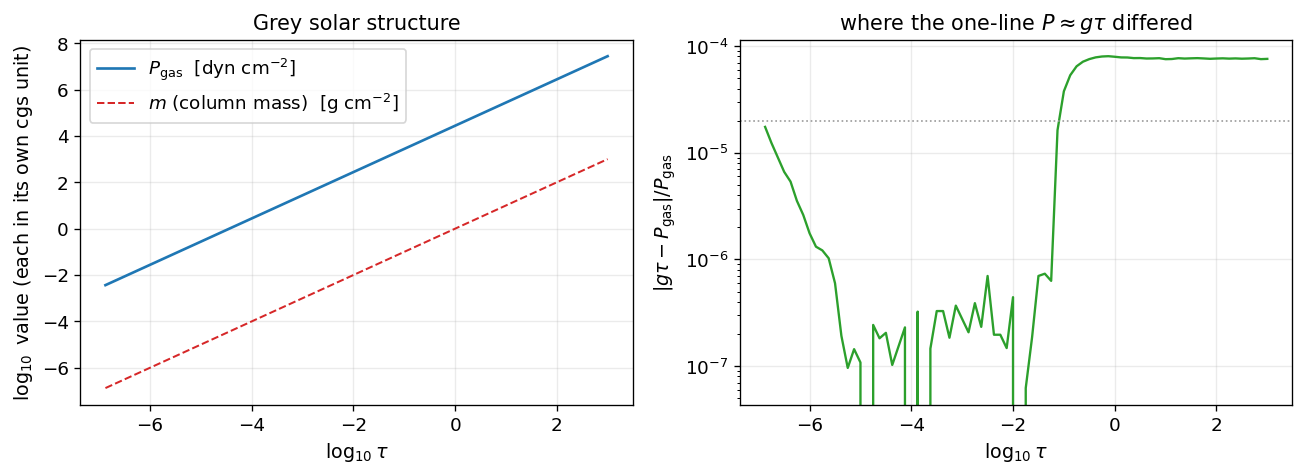

P=g*tau vs P_gas: max frac diff = 8.05e-05


In [10]:
P_analytic = torch.as_tensor(float(g_cgs), dtype=DTYPE, device=DEVICE) * tau
resid = torch.abs(P_analytic - P_gas) / P_gas

x_tau = torch.log10(tau).detach().cpu().to(torch.float64).numpy()
y_pgas = torch.log10(P_gas).detach().cpu().to(torch.float64).numpy()
y_rhox = torch.log10(RHOX).detach().cpu().to(torch.float64).numpy()
y_resid = resid.detach().cpu().to(torch.float64).numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))

ax[0].plot(x_tau, y_pgas, color="C0", lw=1.6, label=r"$P_{\rm gas}$  [dyn cm$^{-2}$]")
ax[0].plot(x_tau, y_rhox, color="C3", lw=1.2, ls="--", label=r"$m$ (column mass)  [g cm$^{-2}$]")
ax[0].set_xlabel(r"$\log_{10}\tau$")
ax[0].set_ylabel(r"$\log_{10}$ value (each in its own cgs unit)")
ax[0].set_title("Grey solar structure")
ax[0].legend(loc="upper left")

ax[1].semilogy(x_tau, y_resid, color="C2", lw=1.4)
ax[1].axhline(2e-5, color="0.6", ls=":", lw=1.0)
ax[1].set_xlabel(r"$\log_{10}\tau$")
ax[1].set_ylabel(r"$|g\tau-P_{\rm gas}|/P_{\rm gas}$")
ax[1].set_title(r"where the one-line $P \approx g\tau$ differed")

fig.tight_layout()
plt.show()

print(f"P=g*tau vs P_gas: max frac diff = {resid.max().detach().cpu().to(torch.float64):.2e}")

The left panel is the grey solar atmosphere — gas pressure and column mass climbing many decades from the thin top layers to the deep base, almost a straight line in log-log because $\kappa\equiv1$ makes $P\approx g\tau$ a power law. The right panel shows where the one-line estimate differed from the stored gas pressure: the offset is small, largest near the upper boundary, and comes from the boundary convention, finite-grid integration, and radiation-pressure subtraction. The production-style integrator closes exactly that gap.

## What this atmosphere is not yet: radiative equilibrium

We have built a structure that satisfies hydrostatic equilibrium — but only with a **placeholder opacity** $\kappa\equiv1$ and a **grey temperature law** that assumed wavelength-independent opacity. Neither is true of a real star.

Lecture 10 takes the second structural constraint, **radiative equilibrium**. In a purely radiative atmosphere the radiative flux is constant with depth; where convection sets in, the conserved quantity is the sum of radiative and convective fluxes. The grey temperature does not satisfy this once the opacity is wavelength-dependent, so the temperature must be corrected layer by layer until the emergent flux matches $\sigma T_{\rm eff}^4$ and the flux divergence vanishes.

Feeding that corrected temperature back into this hydrostatic integration — now with the real Rosseland-mean opacity from the equation of state instead of $\kappa\equiv1$ — and iterating the two to convergence is how ATLAS builds a self-consistent model atmosphere.

That closes the loop the course has been tracing: **parameters $\to$ atmosphere $\to$ spectrum**. The first lectures took the atmosphere as given and turned it into a spectrum; this lecture began the inverse half by building the hydrostatic structure from $T_{\rm eff}$ and $\log g$; and the next lecture makes that structure radiatively self-consistent.

## Synthesis

A model atmosphere is the run of temperature, pressure, and density with depth, fixed by hydrostatic and radiative equilibrium. This lecture built the hydrostatic half. Hydrostatic equilibrium in optical depth is

$$
\frac{dP}{d\tau}=\frac{g}{\kappa},
$$

equivalently $P_{\rm total}=g\,m$ for column mass $m$ up to the top-boundary convention. The grey/Hopf law supplies the temperature, and on the cold start the opacity is the crude placeholder $\kappa\equiv1$, the empty Rosseland table. Integrating the balance in **log pressure** with the Kurucz **predictor-corrector** — including the boundary seed, evaluate-then-check ordering, and radiation-pressure subtraction — gives the gas pressure and column mass to the appropriate float floor.

The computational lesson is just as important as the physics lesson. Most of the setup is naturally vectorized: the grid, the temperature, and radiation pressure are one-dimensional tensor expressions. The hydrostatic integration is not: its four-term Adams history is a true recurrence, so the fixed 80-layer march is the one justified loop in the lecture.

## Summary

- **Hydrostatic equilibrium** in optical depth is $dP/d\tau=g/\kappa$; integrating against column mass gives $P_{\rm total}=g\,m$ up to the boundary constant.
- The **grey/Hopf temperature** is
  $$
  T(\tau)=T_{\rm eff}\left[\frac34\left(0.710+\tau-0.1331e^{-3.4488\tau}\right)\right]^{1/4},
  $$
  evaluated here as one branchless torch tensor operation over all 80 layers.
- The ATLAS cold-start grid has **80 layers**, $\log\tau=-6.875+0.125j$ for $j=0,\ldots,79$.
- Radiation pressure is carried as
  $$
  P_{\rm rad}=2.521\times10^{-15}\max(T^4,\tfrac12T_{\rm eff}^4),
  $$
  and the integrator uses its run relative to the surface.
- The cold start uses $\kappa\equiv1$ because the real Rosseland opacity requires the structure being solved for.
- The TTAUP hydrostatic march integrates in **log pressure** with a predictor-corrector history. It is inherently sequential in depth, so it is a justified fixed-depth loop rather than a vectorized tensor expression.
- The rebuilt `grey_tau`, `grey_T`, `grey_pgas`, and `grey_rhox` arrays match the NumPy-edition reference to the documented float floor on the selected device/dtype.

## Practice exercises

**1. The boundary seed.** The top layer is seeded with $\kappa_0=0.1$ rather than the cold-start value $\kappa=1$ used after evaluation. In a scratch copy of `ttaup`, change `abstd0` to `1.0` and recompute. Which layers move the most? How quickly does the multistep history forget the boundary value?

**2. A hotter, lower-gravity star.** Rebuild the grey atmosphere for an A-type dwarf, $T_{\rm eff}=9000\,\mathrm{K}$ and $\log g=4.0$. Keep all tensors on `DEVICE`. Overplot its $P_{\rm gas}(\tau)$ against the solar result. Why is the gas pressure lower at fixed $\tau$, and where does the radiation-pressure subtraction become more visible?

**3. Why log pressure.** Starting from $dP/d\tau=g/\kappa$ and $p=\ln P$, re-derive
$$
\Delta p=\frac{g}{\kappa}\frac{\tau}{P_{\rm total}}\Delta\ln\tau.
$$
Then solve the cold-start equation analytically for $\kappa\equiv1$ and show that $\log P$ is exactly linear in $\log\tau$.

**4. The evaluate-then-check ordering.** Modify the corrector so that it applies one extra corrector update after the convergence test fires, then rerun the comparison cell. How large is the pressure change? This exercise is a good way to see why reproducing a production code sometimes means reproducing its update ordering, not merely its equations.

**5. Vectorization audit.** Identify which cells are embarrassingly vectorized and which one is a true recurrence. Explain why trying to evaluate all TTAUP layers simultaneously would change the algorithm rather than merely accelerate it.

## Further reading

- **Gray, D. F. (2005). *The Observation and Analysis of Stellar Photospheres*, 3rd ed., Cambridge University Press.** Chapters 7-9 introduce grey atmospheres, hydrostatic equilibrium, and temperature structure.
- **Mihalas, D. (1978). *Stellar Atmospheres*, 2nd ed., Freeman.** Chapter 3 gives the classical construction of model atmospheres and the coupling between hydrostatic and radiative equilibrium.
- **Hubeny, I. & Mihalas, D. (2014). *Theory of Stellar Atmospheres*, Princeton University Press.** A modern, detailed account of stellar-atmosphere structure equations and numerical methods.
- **Kurucz, R. L. (1970). *ATLAS: A Computer Program for Calculating Model Stellar Atmospheres*, SAO Special Report 309.** The original ATLAS description, including the grey cold start and the hydrostatic machinery reproduced here.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The NumPy/Python reference implementation used to generate the parity targets for this book.
- **The source notebooks.** This lecture makes explicit which parts of the hydrostatic start are vectorized tensor algebra and which parts are genuine recurrences.